In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
type(df)

list

In [20]:
file_path="/sales_data_sample.csv"

In [21]:
df=pd.read_csv(r"/sales_data_sample.csv",encoding='latin-1')
df.head(10)

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium
5,10168,36,96.66,1,3479.76,10/28/2003 0:00,Shipped,4,10,2003,...,9408 Furth Circle,NaN,Burlingame,CA,94217,USA,NaN,Hirano,Juri,Medium
6,10180,29,86.13,9,2497.77,11/11/2003 0:00,Shipped,4,11,2003,...,"184, chausse de Tournai",NaN,Lille,NaN,59000,France,EMEA,Rance,Martine,Small
7,10188,48,100.00,1,5512.32,11/18/2003 0:00,Shipped,4,11,2003,...,"Drammen 121, PR 744 Sentrum",NaN,Bergen,NaN,N 5804,Norway,EMEA,Oeztan,Veysel,Medium
8,10201,22,98.57,2,2168.54,12/1/2003 0:00,Shipped,4,12,2003,...,5557 North Pendale Street,NaN,San Francisco,CA,NaN,USA,NaN,Murphy,Julie,Small
9,10211,41,100.00,14,4708.44,1/15/2004 0:00,Shipped,1,1,2004,...,"25, rue Lauriston",NaN,Paris,NaN,75016,France,EMEA,Perrier,Dominique,Medium


In [23]:
df["ORDERDATE"] = pd.to_datetime(df["ORDERDATE"], errors="coerce")

In [25]:
print(df["ORDERDATE"].head())
print(df["ORDERDATE"].dtype)

0   2003-02-24
1   2003-05-07
2   2003-07-01
3   2003-08-25
4   2003-10-10
Name: ORDERDATE, dtype: datetime64[ns]
datetime64[ns]


In [28]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ORDERNUMBER       2823 non-null   int64         
 1   QUANTITYORDERED   2823 non-null   int64         
 2   PRICEEACH         2823 non-null   float64       
 3   ORDERLINENUMBER   2823 non-null   int64         
 4   SALES             2823 non-null   float64       
 5   ORDERDATE         2823 non-null   datetime64[ns]
 6   STATUS            2823 non-null   object        
 7   QTR_ID            2823 non-null   int64         
 8   MONTH_ID          2823 non-null   int64         
 9   YEAR_ID           2823 non-null   int64         
 10  PRODUCTLINE       2823 non-null   object        
 11  MSRP              2823 non-null   int64         
 12  PRODUCTCODE       2823 non-null   object        
 13  CUSTOMERNAME      2823 non-null   object        
 14  PHONE             2823 n

In [30]:
df= df.dropna(subset=["STATE", "ADDRESSLINE2"])

In [32]:
print(df)

      ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER    SALES  \
10          10223               37     100.00                1  3965.66   
11          10237               23     100.00                7  2333.12   
21          10361               20      72.55               13  1451.00   
31          10163               21     100.00                1  4860.24   
40          10270               21     100.00                9  4905.39   
...           ...              ...        ...              ...      ...   
2711        10337               31      89.38                1  2770.78   
2737        10337               36      71.89                7  2588.04   
2764        10361               35     100.00               11  4277.35   
2791        10361               23      95.20               12  2189.60   
2817        10337               42      97.16                5  4080.72   

      ORDERDATE   STATUS  QTR_ID  MONTH_ID  YEAR_ID  ...  \
10   2004-02-20  Shipped       1       

In [33]:
total_sales = df["SALES"].sum()
print("Total Sales:", total_sales)

Total Sales: 903280.85


In [34]:
avg_sales = df.groupby("ORDERNUMBER")["SALES"].sum().mean()
print("Average Sales per Order:", avg_sales)

Average Sales per Order: 36131.234


In [39]:
sales_mean = np.mean(df["SALES"])

In [40]:
print("Mean Sales: ", sales_mean)

Mean Sales:  3613.1234


In [41]:
sales_median = np.median(df["SALES"])

In [44]:
print("Median Sales: ", sales_median)

Median Sales:  3263.96


In [45]:
sales_std = np.std(df["SALES"])

In [46]:
print("Standard Deviation Sales: ", sales_std)

Standard Deviation Sales:  1852.4146095437811


In [48]:
max_sales = df['SALES'].max()

In [49]:
print("Max Sales: ", max_sales)

Max Sales:  11279.2


In [50]:
min_sales = df['SALES'].min()

In [51]:
print("Min Sales: ", min_sales)

Min Sales:  652.35


In [68]:
sales_by_productline = df.groupby('PRODUCTLINE')['SALES'].sum()

In [69]:
print("Sales for Amount of Qunatity Ordered: ", sales_by_productline)

Sales for Amount of Qunatity Ordered:  PRODUCTLINE
Classic Cars        379958.23
Motorcycles         116738.31
Planes               63772.09
Ships                15146.83
Trains                7530.65
Trucks and Buses    120698.50
Vintage Cars        199436.24
Name: SALES, dtype: float64


In [72]:
sales_by_year = df.groupby("YEAR_ID")['SALES'].sum()

In [73]:
print("Sales per Year: ", sales_by_year)

Sales per Year:  YEAR_ID
2003    367221.26
2004    427075.74
2005    108983.85
Name: SALES, dtype: float64


In [75]:
sales_by_dealsize = df.groupby("DEALSIZE")['SALES'].sum()

In [76]:
print("Sales by Deal Size: ", sales_by_dealsize)

Sales by Deal Size:  DEALSIZE
Large     122861.35
Medium    556393.76
Small     224025.74
Name: SALES, dtype: float64


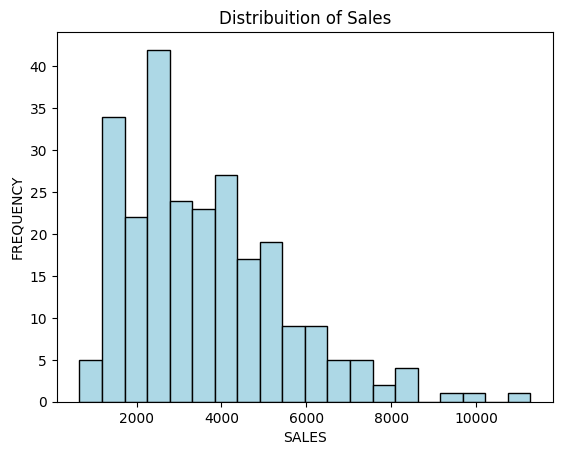

In [86]:
plt.hist(df['SALES'], bins=20, edgecolor='black', color='lightblue')
plt.title("Distribuition of Sales")
plt.xlabel("SALES")
plt.ylabel("FREQUENCY")
plt.show()

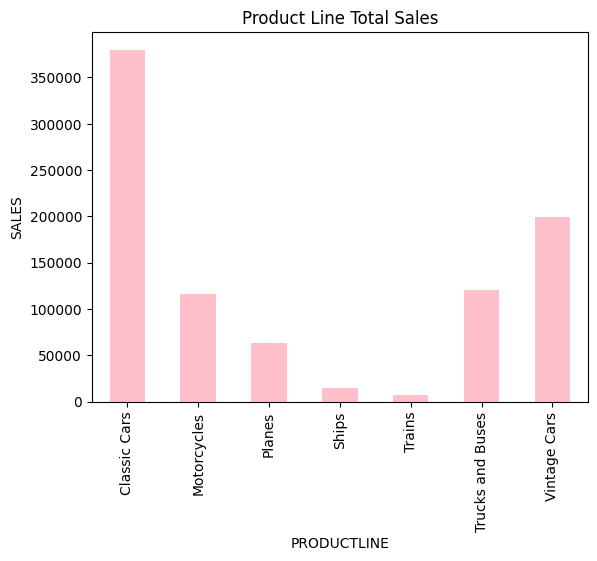

In [84]:
sales_by_productline.plot(kind='bar', color='pink')
plt.title("Product Line Total Sales")
plt.ylabel("SALES")
plt.show()

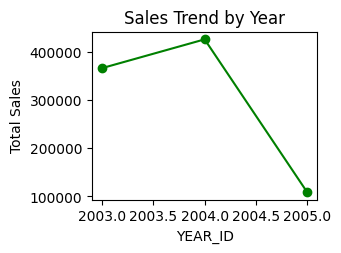

In [83]:
plt.subplot(2,2,3)
sales_by_year.plot(kind='line', marker='o', color='green')
plt.title("Sales Trend by Year")
plt.ylabel("Total Sales")
plt.show()

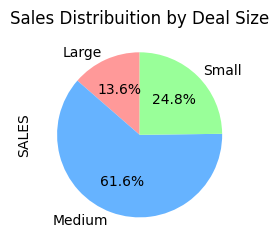

In [93]:
plt.subplot(2,2,4)
sales_by_dealsize.plot(kind='pie',autopct='%1.1f%%', startangle=90, colors=['#ff9999', '#66b3ff', '#99ff99'])
plt.title("Sales Distribuition by Deal Size")
plt.tight_layout()
plt.show()